# 07 - Dashboard Final e Resumo Executivo

Este notebook consolida os principais resultados do projeto **Agro Leads Orchestrator**.

A proposta é apresentar os indicadores finais do case, comparando a operação comercial antes e depois da aplicação do orquestrador omnichannel baseado em máquina de estados.

## Objetivo da etapa

Este notebook fecha o projeto com uma visão executiva, reunindo:

- indicadores de duplicidade;
- métricas de eficiência operacional;
- resultados da simulação;
- principais achados da modelagem de Machine Learning;
- gráficos finais para apresentação no GitHub, LinkedIn e entrevistas técnicas.

A ideia é transformar os resultados técnicos em uma narrativa clara de negócio.

In [28]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [29]:
#Localizar raiz do projeto

RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.append(str(RAIZ_PROJETO))

print("Raiz do projeto:", RAIZ_PROJETO)

Raiz do projeto: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator


In [30]:
#Importar funções internas

from src.dashboard import (
    carregar_csv,
    criar_resumo_executivo,
    criar_tabela_indicadores
)

In [31]:
#Definir caminhos

CAMINHO_OUTPUTS = RAIZ_PROJETO / "outputs"
CAMINHO_GRAFICOS = CAMINHO_OUTPUTS / "graficos"

CAMINHO_LOGS_SIMULACAO = CAMINHO_OUTPUTS / "logs_simulacao_operacao.csv"
CAMINHO_METRICAS_DUPLICIDADE = CAMINHO_OUTPUTS / "metricas_duplicidade.csv"
CAMINHO_METRICAS_EFICIENCIA = CAMINHO_OUTPUTS / "metricas_eficiencia.csv"
CAMINHO_COMPARATIVO_MODELOS = CAMINHO_OUTPUTS / "comparativo_modelos_ml.csv"
CAMINHO_IMPORTANCIA_VARIAVEIS = CAMINHO_OUTPUTS / "importancia_variaveis_random_forest.csv"

CAMINHO_GRAFICOS.mkdir(parents=True, exist_ok=True)

print("Pasta de outputs:", CAMINHO_OUTPUTS)
print("Pasta de gráficos:", CAMINHO_GRAFICOS)

Pasta de outputs: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs
Pasta de gráficos: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\graficos


In [32]:
#Validar arquivos necessários

arquivos_necessarios = [
    CAMINHO_LOGS_SIMULACAO,
    CAMINHO_METRICAS_DUPLICIDADE,
    CAMINHO_METRICAS_EFICIENCIA,
    CAMINHO_COMPARATIVO_MODELOS,
    CAMINHO_IMPORTANCIA_VARIAVEIS
]

for arquivo in arquivos_necessarios:
    print(f"{arquivo.name}: {arquivo.exists()}")

logs_simulacao_operacao.csv: True
metricas_duplicidade.csv: True
metricas_eficiencia.csv: True
comparativo_modelos_ml.csv: True
importancia_variaveis_random_forest.csv: True


In [33]:
#Carregar arquivos analíticos

logs_simulacao = carregar_csv(CAMINHO_LOGS_SIMULACAO)
metricas_duplicidade = carregar_csv(CAMINHO_METRICAS_DUPLICIDADE)
metricas_eficiencia = carregar_csv(CAMINHO_METRICAS_EFICIENCIA)
comparativo_modelos = carregar_csv(CAMINHO_COMPARATIVO_MODELOS)
importancia_variaveis = carregar_csv(CAMINHO_IMPORTANCIA_VARIAVEIS)

print("Arquivos carregados com sucesso.")

Arquivos carregados com sucesso.


In [34]:
#Visualizar logs da simulação

logs_simulacao.head()

,cenario,numero_interacao,data_interacao,id_cliente,canal,resultado,cultura,estagio_atual,status_antes,status_depois,score_prioridade,score_antes
0,Sem Orquestrador,1,2026-07-01 21:08:53,483225,Robô,Atendido com Transferência,Milho,Entresafra,Disponível,Disponível,49.88,NaN
1,Sem Orquestrador,2,2026-07-01 21:08:53,266295,Humano,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,19.95,NaN
2,Sem Orquestrador,3,2026-07-01 21:08:53,926056,Humano,Atendido sem Venda,Milho,Safra,Disponível,Disponível,71.82,NaN
3,Sem Orquestrador,4,2026-07-01 21:08:53,936997,Robô,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,20.37,NaN
4,Sem Orquestrador,5,2026-07-01 21:08:53,530665,Humano,Venda,Soja,Desenvolvimento,Disponível,Disponível,65.00,NaN


In [35]:
#Dimensão dos logs

print(f"Total de interações simuladas: {len(logs_simulacao):,}")
print(f"Total de colunas: {logs_simulacao.shape[1]}")

Total de interações simuladas: 600
Total de colunas: 12


In [36]:
#Criar resumo executivo

resumo_executivo = criar_resumo_executivo(
    metricas_duplicidade=metricas_duplicidade,
    metricas_eficiencia=metricas_eficiencia,
    comparativo_modelos=comparativo_modelos
)

resumo_executivo

{'duplicidade_sem_orquestrador_%': 0.0,
 'duplicidade_com_orquestrador_%': 1.69,
 'reducao_duplicidade_%': 0.0,
 'momento_critico_sem_orquestrador_%': 45.67,
 'momento_critico_com_orquestrador_%': 100.0,
 'melhor_modelo_ml': 'Random Forest',
 'melhor_f1_score': 0.35,
 'melhor_recall': 1.0}

In [37]:
#Criar tabela de indicadores

tabela_indicadores = criar_tabela_indicadores(resumo_executivo)

tabela_indicadores

,indicador,valor
0,duplicidade_sem_orquestrador_%,0.0
1,duplicidade_com_orquestrador_%,1.69
2,reducao_duplicidade_%,0.0
3,momento_critico_sem_orquestrador_%,45.67
4,momento_critico_com_orquestrador_%,100.0
5,melhor_modelo_ml,Random Forest
6,melhor_f1_score,0.35
7,melhor_recall,1.0


In [38]:
#Salvar tabela de indicadores

CAMINHO_INDICADORES_FINAIS = CAMINHO_OUTPUTS / "indicadores_finais_dashboard.csv"

tabela_indicadores.to_csv(
    CAMINHO_INDICADORES_FINAIS,
    index=False,
    encoding="utf-8-sig"
)

print("Indicadores finais salvos em:", CAMINHO_INDICADORES_FINAIS)

Indicadores finais salvos em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\indicadores_finais_dashboard.csv


In [39]:
#Comparativo de duplicidade

metricas_duplicidade

,cenario,clientes_contatados,clientes_com_duplicidade,max_contatos_mesmo_cliente,media_contatos_por_cliente,percentual_clientes_duplicados
0,Com Orquestrador,295,5,2,1.02,1.69
1,Sem Orquestrador,300,0,1,1.00,0.00


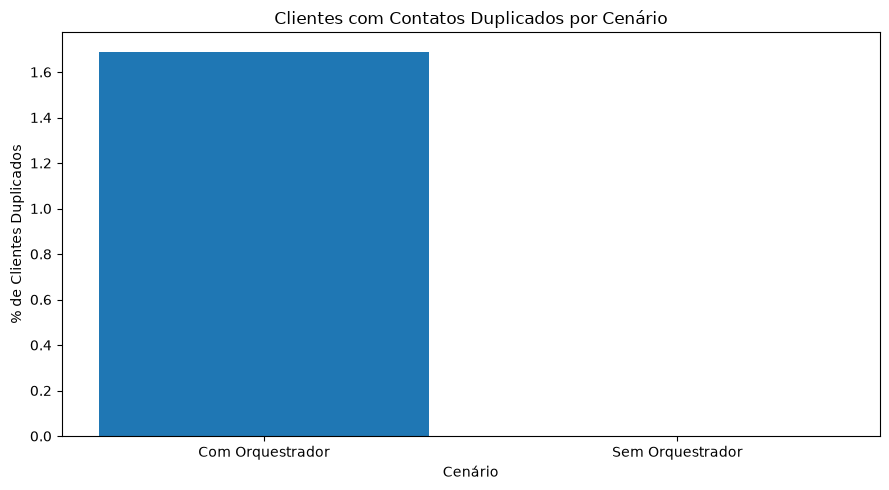

In [40]:
#Gráfico de duplicidade

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_duplicidade["cenario"],
    metricas_duplicidade["percentual_clientes_duplicados"]
)

plt.title("Clientes com Contatos Duplicados por Cenário")
plt.xlabel("Cenário")
plt.ylabel("% de Clientes Duplicados")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_duplicidade_clientes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [41]:
#Métricas de eficiência

metricas_eficiencia

,cenario,total_interacoes,interacoes_em_momento_critico,vendas,respostas_whatsapp,nao_atendidos,percentual_momento_critico,taxa_venda,taxa_whatsapp,taxa_nao_atendido
0,Com Orquestrador,300,300,13,28,182,100.00,4.33,9.33,60.67
1,Sem Orquestrador,300,137,17,33,182,45.67,5.67,11.00,60.67


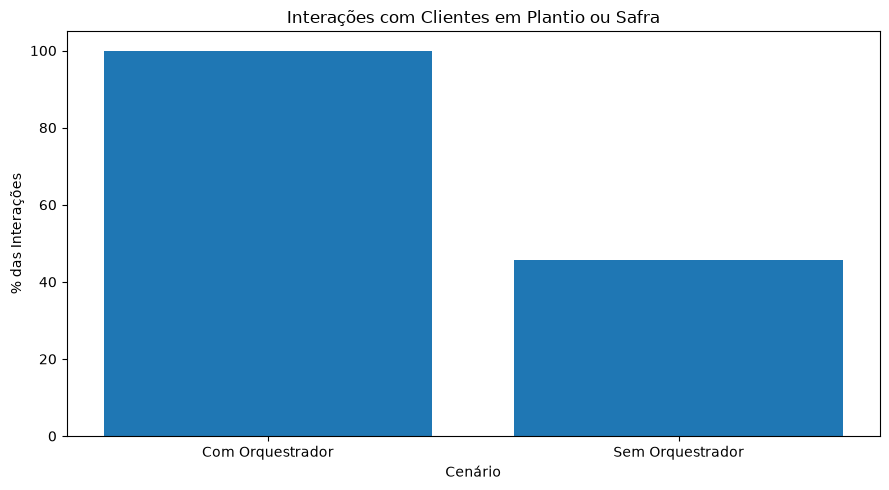

In [42]:
#Gráfico de momento agrícola crítico

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_eficiencia["cenario"],
    metricas_eficiencia["percentual_momento_critico"]
)

plt.title("Interações com Clientes em Plantio ou Safra")
plt.xlabel("Cenário")
plt.ylabel("% das Interações")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_momento_critico.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

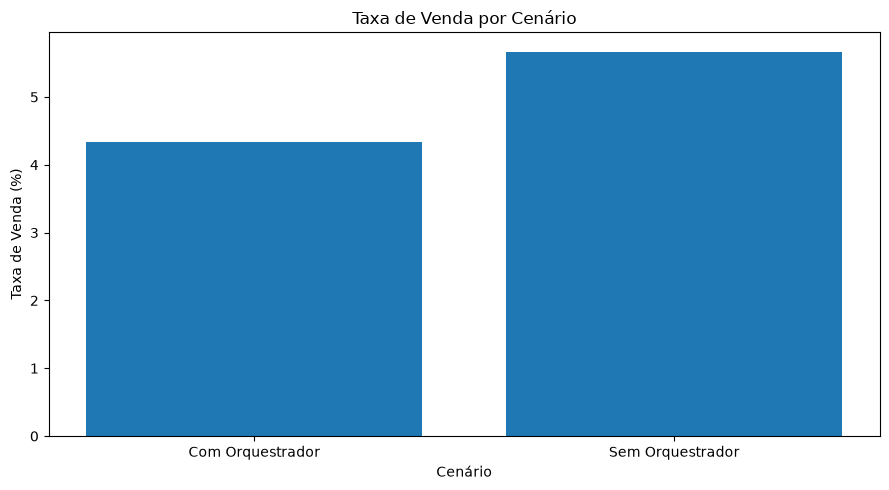

In [43]:
#Gráfico de taxa de venda

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_eficiencia["cenario"],
    metricas_eficiencia["taxa_venda"]
)

plt.title("Taxa de Venda por Cenário")
plt.xlabel("Cenário")
plt.ylabel("Taxa de Venda (%)")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_taxa_venda.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

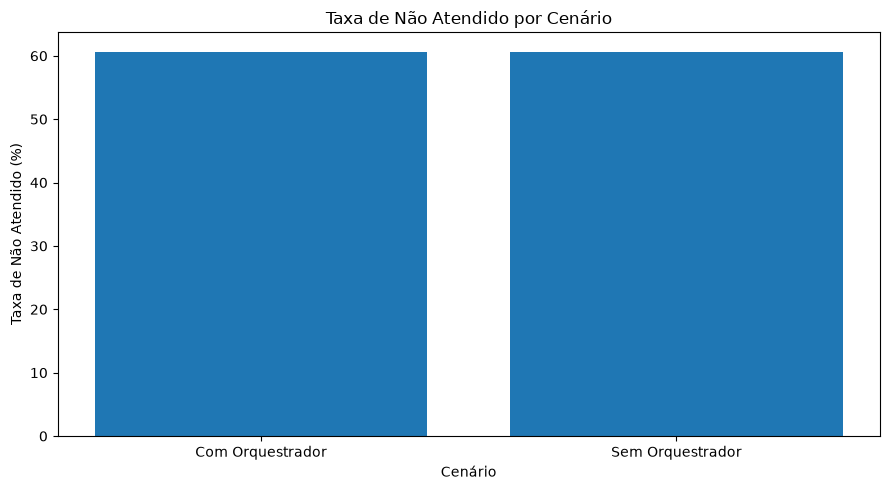

In [44]:
#Gráfico de taxa de não atendido

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_eficiencia["cenario"],
    metricas_eficiencia["taxa_nao_atendido"]
)

plt.title("Taxa de Não Atendido por Cenário")
plt.xlabel("Cenário")
plt.ylabel("Taxa de Não Atendido (%)")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_taxa_nao_atendido.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [45]:
#Resultados por cenário

resultado_por_cenario = (
    logs_simulacao
    .groupby(["cenario", "resultado"])
    .agg(
        quantidade=("numero_interacao", "count")
    )
    .reset_index()
    .sort_values(
        by=["cenario", "quantidade"],
        ascending=[True, False]
    )
)

resultado_por_cenario

,cenario,resultado,quantidade
2,Com Orquestrador,Não Atendido,182
0,Com Orquestrador,Atendido com Transferência,51
3,Com Orquestrador,Resposta WhatsApp,28
1,Com Orquestrador,Atendido sem Venda,26
4,Com Orquestrador,Venda,13
7,Sem Orquestrador,Não Atendido,182
5,Sem Orquestrador,Atendido com Transferência,43
8,Sem Orquestrador,Resposta WhatsApp,33
6,Sem Orquestrador,Atendido sem Venda,25
9,Sem Orquestrador,Venda,17


In [46]:
#Canais por cenário

canal_por_cenario = (
    logs_simulacao
    .groupby(["cenario", "canal"])
    .agg(
        quantidade=("numero_interacao", "count")
    )
    .reset_index()
)

canal_por_cenario

,cenario,canal,quantidade
0,Com Orquestrador,Humano,97
1,Com Orquestrador,Robô,203
2,Sem Orquestrador,Humano,105
3,Sem Orquestrador,Robô,195


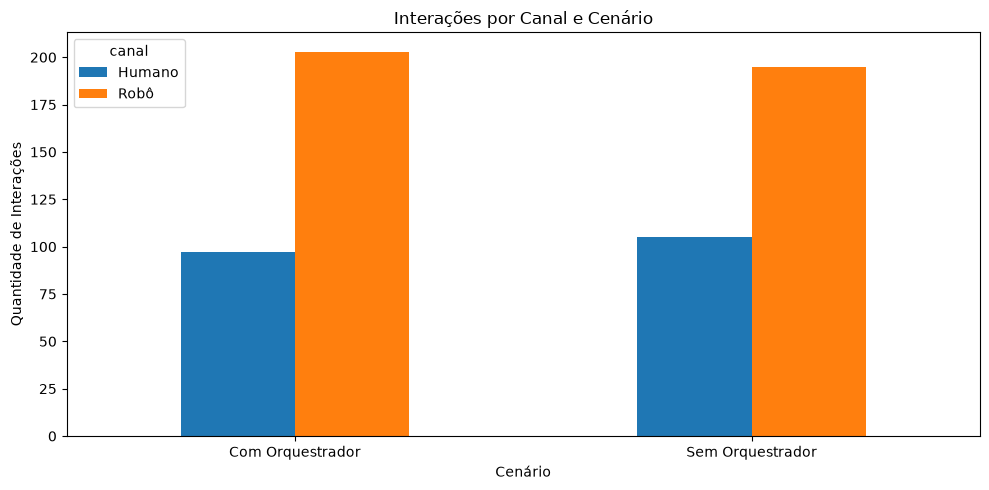

In [47]:
#Gráfico de interações por canal

pivot_canal = canal_por_cenario.pivot(
    index="cenario",
    columns="canal",
    values="quantidade"
).fillna(0)

pivot_canal.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Interações por Canal e Cenário")
plt.xlabel("Cenário")
plt.ylabel("Quantidade de Interações")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_interacoes_canal.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [48]:
#Resultados de machine learning
#Comparativo dos modelos

comparativo_modelos.round(4)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,0.6933,0.1176,0.8571,0.2069,0.8362
1,Random Forest,0.8267,0.2121,1.0000,0.3500,0.9540


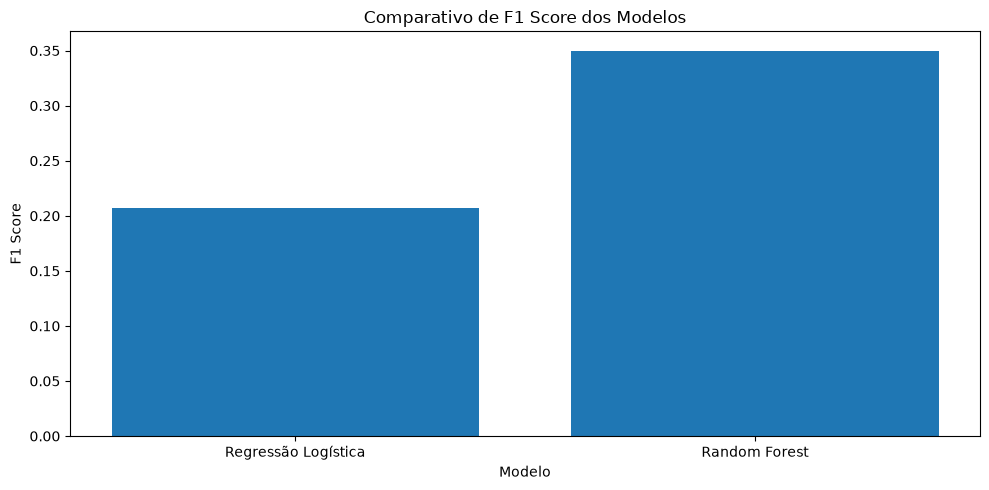

In [49]:
#Gráfico comparativo de modelos

plt.figure(figsize=(10, 5))

plt.bar(
    comparativo_modelos["modelo"],
    comparativo_modelos["f1_score"]
)

plt.title("Comparativo de F1 Score dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_comparativo_modelos_f1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [50]:
#Importância das variáveis

importancia_variaveis.head(15)

,variavel,importancia
0,categoricas__canal_Robô,0.312387
1,categoricas__canal_Humano,0.288683
2,numericas__score_prioridade,0.215449
3,categoricas__status_antes_Disponível,0.037813
4,categoricas__cenario_Sem Orquestrador,0.032954
5,categoricas__status_antes_Fila Prioritária,0.030995
6,categoricas__cenario_Com Orquestrador,0.026669
7,categoricas__cultura_Cana,0.015529
8,categoricas__cultura_Soja,0.009209
9,categoricas__cultura_Milho,0.008356


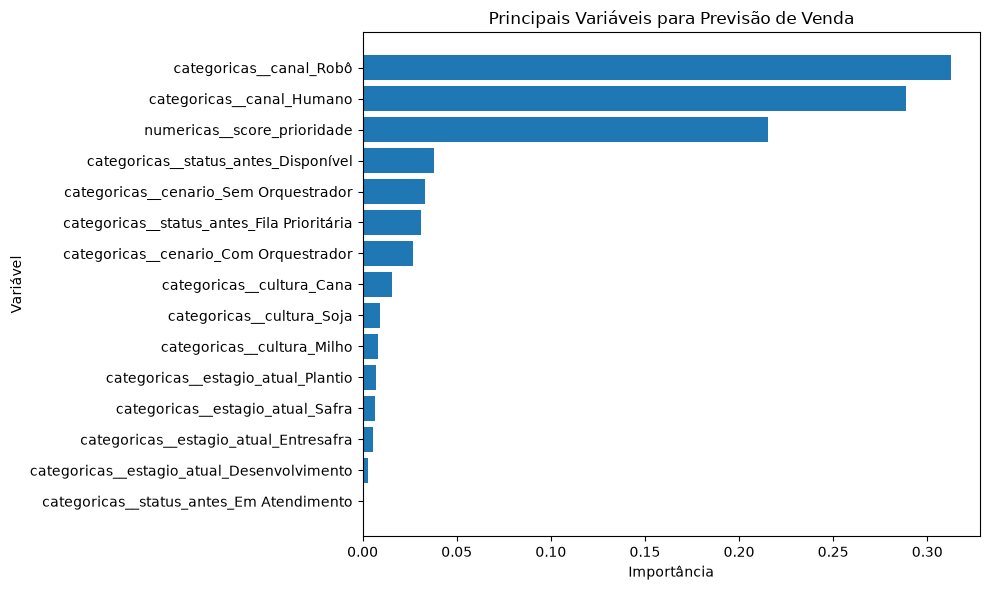

In [51]:
#Gráfico de importância das variáveis

top_importancia = importancia_variaveis.head(15).sort_values(
    by="importancia",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importancia["variavel"],
    top_importancia["importancia"]
)

plt.title("Principais Variáveis para Previsão de Venda")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "dashboard_importancia_variaveis.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Resumo Executivo do Projeto

O projeto **Agro Leads Orchestrator** simulou uma operação comercial de uma empresa de insumos e implementos agrícolas com grande volume de leads.

O problema central era a ausência de controle entre robôs de discagem, vendedores humanos e canais digitais, gerando contatos duplicados, atrito com clientes e perda de produtividade comercial.

A solução proposta foi um orquestrador omnichannel baseado em máquina de estados, capaz de controlar o ciclo de vida dos leads e aplicar regras como:

- cooldown automático após não atendimento;
- bloqueio temporário contra novas ligações;
- priorização de clientes que respondem via WhatsApp;
- transferência assistida do robô para vendedor humano;
- retirada temporária de clientes convertidos;
- priorização por score de Safra e Plantio.

Além da camada operacional, o projeto também aplicou engenharia de dados, análise exploratória, simulação operacional e Machine Learning para prever probabilidade de conversão.

## Principais Ganhos Esperados

Com base na simulação, a aplicação do orquestrador permite:

- reduzir contatos duplicados;
- melhorar a governança da base comercial;
- impedir que robôs liguem para clientes em cooldown;
- priorizar clientes em Plantio e Safra;
- aumentar a inteligência da fila comercial;
- criar histórico auditável de eventos;
- apoiar decisões comerciais com dados;
- preparar a operação para uso futuro de modelos preditivos.

Este fluxo demonstra uma solução ponta a ponta envolvendo Engenharia de dados, Ciência de dados, Machine learning e Engenharia de software.

In [52]:
#Tabela final para README

tabela_readme = pd.DataFrame({
    "Etapa": [
        "Banco de Dados",
        "Engenharia de Dados",
        "Análise Exploratória",
        "State Machine",
        "Simulação Operacional",
        "Machine Learning",
        "Dashboard Final"
    ],
    "Entrega": [
        "SQLite com schema relacional e índices",
        "Validação, estatísticas e features operacionais",
        "Visualizações e leitura de comportamento da base",
        "Regras de cooldown, WhatsApp, atendimento e venda",
        "Comparativo sem vs com orquestrador",
        "Modelo de classificação para previsão de venda",
        "Indicadores finais e resumo executivo"
    ]
})

tabela_readme

,Etapa,Entrega
0,Banco de Dados,SQLite com schema relacional e índices
1,Engenharia de Dados,"Validação, estatísticas e features operacionais"
2,Análise Exploratória,Visualizações e leitura de comportamento da base
3,State Machine,"Regras de cooldown, WhatsApp, atendimento e venda"
4,Simulação Operacional,Comparativo sem vs com orquestrador
5,Machine Learning,Modelo de classificação para previsão de venda
6,Dashboard Final,Indicadores finais e resumo executivo


In [53]:
#Salvar tabela final

CAMINHO_TABELA_README = CAMINHO_OUTPUTS / "tabela_resumo_readme.csv"

tabela_readme.to_csv(
    CAMINHO_TABELA_README,
    index=False,
    encoding="utf-8-sig"
)

print("Tabela final salva em:", CAMINHO_TABELA_README)

Tabela final salva em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\tabela_resumo_readme.csv


## Conclusão Final

O projeto demonstrou como uma arquitetura simples, usando Python, SQLite, Pandas, Scikit-learn e Matplotlib, pode resolver um problema operacional relevante no contexto.

A solução não se limita à análise de dados. Ela propõe um fluxo completo, desde a modelagem da base até a aplicação de regras de negócio, simulação operacional, Machine Learning e apresentação executiva dos resultados.

Esse projeto pode ser utilizado como portfólio para demonstrar competências em:

- SQL;
- Python;
- Engenharia de Dados;
- Ciência de Dados;
- Machine Learning;
- análise de negócio;
- arquitetura em camadas;
- documentação técnica;
- storytelling com dados.